In [1]:
import torch
import os
import random
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from torchvision.utils import make_grid
#from modules_energy_score_xinwei import StoNet
from engression.models import StoNet, StoLayer
#from loss_func import energy_loss_two_sample
from engression.loss_func import energy_loss_two_sample
import argparse
import json
import xarray as xr
import torch.nn as nn

#from utils_cordex_v2 import get_data_cordex_v2
#from utils_cordex_v4 import get_data_cordex_v3
#from config import get_config
#from utils import *
#from models_cnn import cGenerator
import sys
#sys.path.append("..")

In [2]:
def standardize_numpy(X):
    mean = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True)
    return (X - mean) / (std), mean, std
    
def visual_sample(model_enc, model_dec, model_pred, x, y, save_dir, to_img=True):
    model_enc.eval()
    model_dec.eval()
    model_pred.eval()
    with torch.no_grad():
        # gen = model(x).detach().cpu()#.view(x.shape[0], 1, 128, 128)
        rec1 = model_dec(model_enc(y)).detach().cpu()
        rec2 = model_dec(model_enc(y)).detach().cpu()
            
        gen1 = model_dec(model_pred(x)).detach().cpu()
        gen2 = model_dec(model_pred(x)).detach().cpu()
    if to_img:
        rec1 = rec1.view(x.shape[0], 1, 128, 128)
        rec2 = rec2.view(x.shape[0], 1, 128, 128)
        gen1 = gen1.view(x.shape[0], 1, 128, 128)
        gen2 = gen2.view(x.shape[0], 1, 128, 128)
        y = y.view(y.shape[0], 1, 128, 128)
    # y = y.cpu().view(y.shape[0], 1, 128, 128)
    sample = torch.cat([y.cpu(), rec1, rec2, gen1, gen2])
    sample = torch.clamp(sample, torch.quantile(y, 0.005).item(), torch.quantile(y, 0.995).item())
    plt.matshow(make_grid(sample, nrow=y.shape[0]).permute(1, 2, 0)[:,:,0], cmap="Spectral_r"); plt.axis('off'); 
    plt.savefig(save_dir, bbox_inches="tight", pad_inches=0, dpi=300); plt.close()
    # save_image(sample, save_dir, normalize=True, scale_each=True)
    model_enc.train()
    model_dec.train()
    model_pred.train()

def data_to_torch(ds, variable):
    temp_data = ds[variable]
    data = temp_data.transpose('time', 'lat', 'lon')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)
    
    # Flatten lat and lon together
    time_steps, lat_dim, lon_dim = data_np.shape
    data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

def predictors_to_torch(ds, variable):
    temp_data = ds#[variable]
    data = temp_data.transpose('time', 'mode')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)

    
    # Flatten lat and lon together
    #time_steps, lat_dim, lon_dim = data_np.shape
    #data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    #data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

In [3]:
#if __name__ == '__main__':

#args = get_config()

random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#device = torch.device('cuda')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

#if args.cnn:
#    save_dir = f'results/eng/nm{args.n_models}/cnn_lat{args.latent_dim}'
#else:
#    save_dir = f"results/{args.method}/nm{args.n_models}_un/layer{args.num_layer}_hidden{args.hidden_dim}_noise{args.noise_dim}{args.save_name}/"

save_dir = "joint_low_level_out"
#make_folder(save_dir)
#write_config_to_file(args, save_dir)

device: cuda


In [4]:
#### load data

#train_loader, test_loader_in, test_loader_out = get_data_cordex_v3(args.n_models, variables = args.variables)
#print('#training batches:', len(train_loader))
#x_tr_eval, y_tr_eval = data2pair(next(iter(train_loader)), n=args.n_visual, device=device, keep_img=args.cnn, rank = args.rank)
#x_te_eval, y_te_eval = data2pair(next(iter(test_loader_in)), n=args.n_visual, device=device, keep_img=args.cnn, rank = args.rank)

# read contents from the settings.json file
settings_file_path = 'dpa_train_settings.json'

with open(settings_file_path, 'r') as file:
    settings = json.load(file)


# Create directories
#os.makedirs(output_dir, exist_ok=True)    

# Save to a new file for logging
with open(f"{save_dir}/used_settings.json", "w") as f:
    json.dump(settings, f, indent=4)

# load my temperature data
# Load your NetCDF file
ds = xr.open_dataset(settings['dataset_trefht'])

ds_train = ds.isel(time=slice(0, 128000)) #4769 * 80
ds_test = ds.isel(time=slice(-64000, 476900)) #4769 * 80

# transform to torch tensors
x_tr = data_to_torch(ds_train, "TREFHT")
x_te = data_to_torch(ds_test, "TREFHT")

# load Z500
ds_z500_pre = xr.open_dataset(settings['dataset_z500'])
ds_z500, _, _ = standardize_numpy(ds_z500_pre.pseudo_pcs.values)
print("z500 shape", ds_z500.shape)
z500 = torch.from_numpy(ds_z500) #predictors_to_torch(ds_z500, "pseudo_pcs")
print("z500 shape", z500.shape)
# scale Z500


z500_train = z500[:128000,:]#[:381520,:]
z500_test = z500[-64000:,:]

torch.Size([128000, 1024])
torch.Size([64000, 1024])
z500 shape (476900, 1000)
z500 shape torch.Size([476900, 1000])


In [5]:
#### build model
#if args.method == 'eng':
    #if args.cnn:
    #    model = cGenerator(args.latent_dim, args.g_conv_dim, args.image_size, out_channels=1, tanh=False, add_noise=True,
    #                        cond_dim=x_tr_eval.shape[1], prior_num_layer=args.prior_layer, prior_hidden_dim=args.prior_fc_size,
    #                        prior_dist=args.prior, latent_noise_dim=args.latent_noise_dim).to(device)
    #else:
in_dim = 1024
latent_dim = 20
num_layers = 6
hidden_dim = 100
noise_dim = 20
bn = False
resblock = True
noise_std = 1
out_act=None
noise_dim_dec=20
lr = 1e-4

# Encoder
model_enc = StoNet(in_dim=in_dim,
                   out_dim=latent_dim,
                   num_layer=num_layers,
                   hidden_dim=hidden_dim,
                   noise_dim=0,
                   add_bn=bn,
                   out_act=out_act,
                   resblock=resblock).to(device)
# Decoder
model_dec = StoNet(in_dim=latent_dim,
                   out_dim=in_dim,
                   num_layer=num_layers,
                   hidden_dim=hidden_dim,
                   noise_dim=noise_dim_dec,
                   add_bn=bn,
                   out_act=out_act,
                   resblock=resblock).to(device)
# Latent Map
model_pred = nn.Linear(1000, latent_dim).to(device)

optimizer = torch.optim.Adam(list(model_enc.parameters()) + list(model_dec.parameters()),lr=lr)
optimizer_lm = torch.optim.Adam(list(model_pred.parameters()), lr=lr)

In [6]:
# prepare data
from torch.utils.data import TensorDataset, DataLoader

batch_size = 128 #190
# create data loader Temperature
train_dataset = TensorDataset(x_tr, x_tr)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print(f"Number of batches: {len(train_loader)}")

# create data loader Z500
train_dataset_z500 = TensorDataset(z500_train)
train_loader_z500 = DataLoader(train_dataset_z500, batch_size=batch_size, shuffle=True)
print(f"Number of batches: {len(train_loader_z500)}")

# create test loader Temperature
test_dataset = TensorDataset(x_te, x_te)
test_loader_in = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f"Number of batches: {len(test_loader_in)}")

# create test data loader Z500
dataset_z500_test = TensorDataset(z500_test)
test_loader_z500 = DataLoader(dataset_z500_test, batch_size=batch_size, shuffle=False)
print(f"Number of batches: {len(test_loader_z500)}")


Number of batches: 1000
Number of batches: 1000
Number of batches: 500
Number of batches: 500


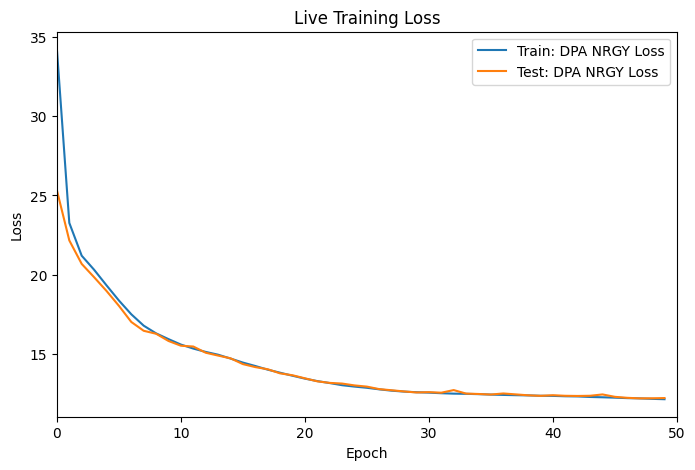

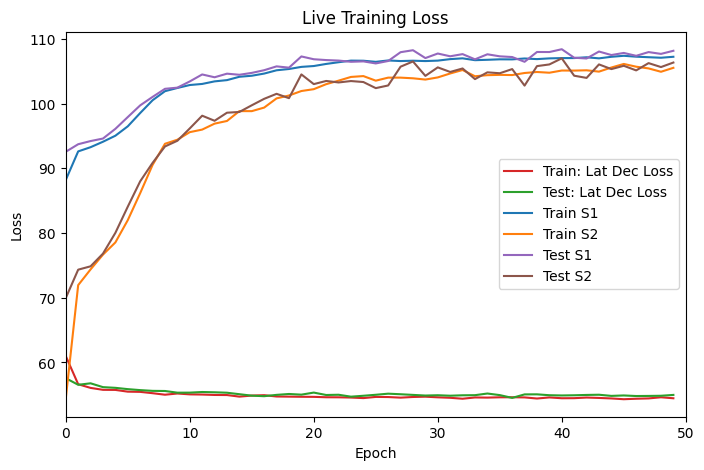

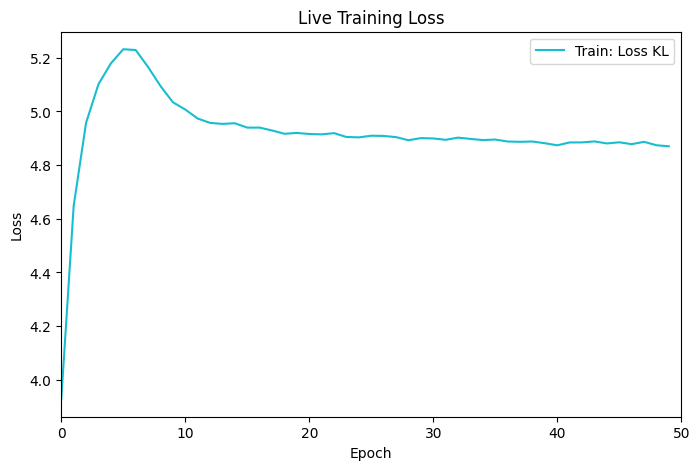

In [7]:
epochs = 20
# data
beta = 1
loss_fn = nn.MSELoss()
print_every_nepoch = 1
save_model_every = 100
losses_dpa_only_list_tr=[]
losses_dpa_only_list_te=[]
losses_lin_lat_pred_tr = []
losses_lin_lat_pred_te = []
losses_s1_lat_dec_tr = []
losses_s2_lat_dec_tr = []
losses_s1_lat_dec_te = []
losses_s2_lat_dec_te = []
losses_kl = []

training_epochs = 50
epochs_list=[]

log_file_name = os.path.join(save_dir, 'log.txt')

#if args.resume_epoch > 0:
#    log_file = open(log_file_name, "at")
#else:
log_file = open(log_file_name, "wt")
    
for epoch_idx in range(0, training_epochs):
    #print("Epoch:", epoch_idx)
    total_loss_tr_dpa = 0
    nrgy_loss_dpa_only = 0
    pred_loss_lin_lat = 0

    s1_lat_dec_tr = 0
    s2_lat_dec_tr = 0

    s1_lat_dec_te = 0
    s2_lat_dec_te = 0
    
    loss_dpa_only_te = 0
    pred_loss_lin_lat_te = 0
    total_loss_te = 0

    loss_kl_latent = 0

    
    
    
    #s1_tr = 0
    #s1_tr_pred = 0
    #s2_tr = 0
    #s2_tr_pred = 0
   # 
    #for batch_idx, data_batch in enumerate(train_loader):
    for batch_idx, (data_batch, slp_batch) in enumerate(zip(train_loader, train_loader_z500)):
        optimizer.zero_grad()
        optimizer_lm.zero_grad()
        ### added by FL ###
        #print("batch idx", batch_idx)
        #print("Data batch length", len(data_batch))
        #print("Data batch shape", data_batch[0].shape)
        
        # add Gaussian noise of shape [128, 20]
        #x1 = torch.cat([slp_batch[0], torch.randn(batch_size, 20)], dim=1).to(device)
        #x2 = torch.cat([slp_batch[0], torch.randn(batch_size, 20)], dim=1).to(device)

        x1 = slp_batch[0].to(device)
        x2 = slp_batch[0].to(device)

        #print("x shape:", x.shape)
        y = data_batch[0].to(device)
        #print(x.shape, x.device)
        #print(y.device)

        ###################
        # TRAIN DPA
        # encode training sample
        optimizer.zero_grad()
        e = model_enc(y)

        # decode
        rec1 = model_dec(e) 
        rec2 = model_dec(e)

        # 2 linear latent predictions
        # with different noise
        model_pred.eval()
        z1 = model_pred(x1).detach() # to make gradients not flow through
        z2 = model_pred(x2).detach()
        model_pred.train()
        
        #print("z1 shape:", z1.shape)
        gen1 = model_dec(z1)
        gen2 = model_dec(z2)

        # compute energy loss 
        loss_rec, s1_rec, s2_rec = energy_loss_two_sample(y, rec1, rec2, verbose=True, beta=beta)
        #print("loss_rec:", loss_rec.grad_fn)
        #print("first energy loss computed")

        # DPA Loss
        # gen1,2: latent linear predictions decoded
        loss_lin_latent_pred, s1_pred, s2_pred = energy_loss_two_sample(y, gen1, gen2, verbose=True, beta=beta)

        # KL similar loss
        penalty_e = torch.linalg.vector_norm(e.std(dim=0) - 1) + torch.linalg.vector_norm(e.mean(dim=0)) # penalizes deviations from std=1 and mean = 0 for encoded sample 
        penalty_gen = torch.linalg.vector_norm(z1.std(dim=0) - 1) + torch.linalg.vector_norm(z1.mean(dim=0)) # penalizes deviations from std=1 and mean = 0 for predicted latent sample
        loss_kl = penalty_e + penalty_gen
        
        loss_dpa = loss_rec + loss_lin_latent_pred + loss_kl
        
        loss_dpa.backward()
        optimizer.step()

        # save losses
        total_loss_tr_dpa += loss_dpa.item()
        nrgy_loss_dpa_only += loss_rec.item()
        pred_loss_lin_lat += loss_lin_latent_pred.item()

        s1_lat_dec_tr += s1_pred.item()
        s2_lat_dec_tr += s2_pred.item()

        loss_kl_latent += loss_kl.item()

        

        ######################
        # Train latent map

        # set gradients to zero
        optimizer_lm.zero_grad()
        
        # encode training sample with updated DPA
        # need to set model_enc() to evaluate() ?
        
        model_enc.eval()
        e_l = model_enc(y).detach() # to make gradients not flow through
        model_enc.train()
        z1_lm = model_pred(x1) 
        z2_lm = model_pred(x2)
        
        # Latent Map loss
        z1_loss = loss_fn(e_l, z1_lm) # use the same linear latent predictions as latent map wasn't updated yet
        z2_loss = loss_fn(e_l, z2_lm)
        latent_map_loss = (z1_loss+z2_loss)/2
        #print("latent_map_loss:", latent_map_loss.grad_fn)

        latent_map_loss.backward()
        optimizer_lm.step()
        
        ########################
        
        
        #loss_tr += loss.item()
        #s1_tr += s1_rec.item() + s1_pred.item()
        #s2_tr += s2_rec.item() + s2_pred.item()
        
        #loss_tr_pred += loss_pred.item()
        #s1_tr_pred += s1_pred.item()            
        #s2_tr_pred += s2_pred.item()

        

        
    
    if (epoch_idx == 0 or (epoch_idx + 1) % print_every_nepoch == 0):
        log = f'[Epoch {epoch_idx + 1} Train]\tloss_dpa: {total_loss_tr_dpa / len(train_loader):.4f}, loss_nrgy_dpa: {nrgy_loss_dpa_only / len(train_loader):.4f}, loss_lat_dec: {pred_loss_lin_lat / len(train_loader):.4f}, s1_lat_dec_train: {s1_lat_dec_tr/ len(train_loader):.4f}, s2_lat_dec_train: {s2_lat_dec_tr/ len(train_loader):.4f}, loss_kl: {loss_kl_latent / len(train_loader):.4f}'
        
        if epoch_idx == 0 or ((epoch_idx + 1) % (print_every_nepoch) == 0):
            model_enc.eval()
            model_dec.eval()
            model_pred.eval()
            loss_dpa_only_te = 0; pred_loss_lin_lat_te = 0; total_loss_te = 0
            with torch.no_grad():
                #for data_te in test_loader_in:
                for (test_batch, slp_test_batch) in zip(test_loader_in, test_loader_z500):
                    #x_te, y_te = data2pair(data_te, device=device, rank=args.rank)
                    y_te = test_batch[0].to(device)
                    #print("test shapes:", slp_test_batch[0].shape, torch.randn(batch_size, 20).shape)
                    #x_te = torch.cat([slp_test_batch[0], torch.randn(batch_size, 20)], dim=1).to(device)
                    x_te = slp_test_batch[0].to(device)

                    
                    rec1_te = model_dec(model_enc(y_te))
                    rec2_te = model_dec(model_enc(y_te))
                    
                    gen1_te = model_dec(model_pred(x_te))
                    gen2_te = model_dec(model_pred(x_te))
                    
                    loss_dpa_only_te += energy_loss_two_sample(y_te, rec1_te, rec2_te, beta=1)[0].item()
                    pred_loss_lin_lat_te += energy_loss_two_sample(y_te, gen1_te, gen2_te, beta=1)[0].item()
                    total_loss_te += loss_dpa_only_te + pred_loss_lin_lat_te

                    s1_lat_dec_te += energy_loss_two_sample(y_te, gen1_te, gen2_te, beta=1)[1].item()
                    s2_lat_dec_te += energy_loss_two_sample(y_te, gen1_te, gen2_te, beta=1)[2].item()
                    
            log += f'\n  Test  \tloss total test: {total_loss_te / len(test_loader_in):.4f}, loss_dpa_only: {loss_dpa_only_te / len(test_loader_in):.4f}, pred_loss_latent_map: {pred_loss_lin_lat_te / len(test_loader_in):.4f}, s1_lat_dec_te: {s1_lat_dec_te/ len(test_loader_in):.4f}, s2_lat_dec_te: {s2_lat_dec_te/ len(test_loader_in):.4f}'
            model_enc.train()
            model_dec.train()
            model_pred.train()
        
        print(log)
        log_file.write(log + '\n')
        log_file.flush()
    
    #if (epoch_idx == 0 or (epoch_idx + 1) % args.sample_every_nepoch == 0):
        
    #    visual_sample(model_enc, model_dec, model_pred, x_tr_eval, y_tr_eval, save_dir=save_dir + f'img_{epoch_idx + 1}_tr.png', to_img=~args.cnn)
    #    visual_sample(model_enc, model_dec, model_pred, x_te_eval, y_te_eval, save_dir=save_dir + f'img_{epoch_idx + 1}_te.png', to_img=~args.cnn)
    
    if (epoch_idx + 1) % save_model_every == 0:# and i >= 30:
        torch.save(model_enc.state_dict(), save_dir + "model_enc_" + str(epoch_idx + 1) + ".pt")
        torch.save(model_dec.state_dict(), save_dir + "model_dec_" + str(epoch_idx + 1) + ".pt")
        torch.save(model_pred.state_dict(), save_dir + "model_pred_" + str(epoch_idx + 1) + ".pt")

    epochs_list.append(epoch_idx)
    losses_dpa_only_list_tr.append(nrgy_loss_dpa_only / len(train_loader))
    losses_dpa_only_list_te.append(loss_dpa_only_te / len(test_loader_in))
    losses_lin_lat_pred_tr.append(pred_loss_lin_lat / len(train_loader))
    losses_lin_lat_pred_te.append(pred_loss_lin_lat_te / len(test_loader_in))
    losses_s1_lat_dec_tr.append(s1_lat_dec_tr / len(train_loader))
    losses_s2_lat_dec_tr.append(s2_lat_dec_tr / len(train_loader))
    
    losses_s1_lat_dec_te.append(s1_lat_dec_te / len(test_loader_in))
    losses_s2_lat_dec_te.append(s2_lat_dec_te / len(test_loader_in))

    losses_kl.append(loss_kl_latent / len(train_loader))
    

    # 🔁 Dynamic plot
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.plot(losses_dpa_only_list_tr, label="Train: DPA NRGY Loss", color='tab:blue')
    plt.plot(losses_dpa_only_list_te, label="Test: DPA NRGY Loss", color='tab:orange')
    



    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Live Training Loss")
    plt.legend()
    #plt.grid(True)
    #plt.ylim(0,30)
    #plt.xticks(ticks=range(0, training_epochs, 1))
    plt.xlim(0,training_epochs)
    plt.show()


    plt.figure(figsize=(8, 5))
    plt.plot(losses_lin_lat_pred_tr, label="Train: Lat Dec Loss", color='tab:red')
    plt.plot(losses_lin_lat_pred_te, label="Test: Lat Dec Loss", color='tab:green')
    plt.plot(losses_s1_lat_dec_tr, label = "Train S1", color='tab:blue')
    plt.plot(losses_s2_lat_dec_tr, label = "Train S2", color='tab:orange')
    plt.plot(losses_s1_lat_dec_te, label = "Test S1", color='tab:purple')
    plt.plot(losses_s2_lat_dec_te, label = "Test S2", color='tab:brown')


    


    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Live Training Loss")
    plt.legend()
    #plt.grid(True)
    #plt.ylim(0,30)
    #plt.xticks(ticks=range(0, training_epochs, 1))
    plt.xlim(0,training_epochs)
    plt.show()


    plt.figure(figsize=(8, 5))
    plt.plot(losses_kl, label="Train: Loss KL", color='tab:cyan')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Live Training Loss")
    plt.legend()
    #plt.grid(True)
    #plt.ylim(0,30)
    #plt.xticks(ticks=range(0, training_epochs, 1))
    plt.xlim(0,training_epochs)
    plt.show()